## Resumen
Este notebook replica para Malawi 2004 la comparacion encuesta vs GlobalDist en 1000 bins, verificando consistencia de columnas, diferencias por bin y desviaciones de la media.

# Malawi 2004: Survey Bins vs Global 1000-Bin Distribution

Objective: replicate the Malawi 1997 bin-comparison workflow for Malawi 2004.

This notebook first validates whether the 2004 microdata has a compatible structure with Malawi 1997, and then applies the same reconstruction and comparison pipeline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
ROOT = Path(".").resolve()
INPUT = ROOT / "01-input"
WORK = ROOT / "work"

mwi_1997_path = INPUT / "country" / "MWI_1997.dta"
mwi_2004_path = INPUT / "country" / "MWI_2004.dta"
global_bins_path = INPUT / "GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta"
pip_path = INPUT / "pip_1kbins.dta"

mwi_1997_path, mwi_2004_path, global_bins_path, pip_path

(WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/01-input/country/MWI_1997.dta'),
 WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/01-input/country/MWI_2004.dta'),
 WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/01-input/GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta'),
 WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/01-input/pip_1kbins.dta'))

## 1. Load Malawi 1997 and 2004 Datasets

We first check structure compatibility before running the 2004 reconstruction pipeline.

In [3]:
required_cols = ["welfare", "weight", "cpi2021", "icp2021", "year", "survname"]

if not mwi_1997_path.exists():
    raise RuntimeError(f"Missing baseline microdata file: {mwi_1997_path}")

mwi_1997 = pd.read_stata(mwi_1997_path, convert_categoricals=False)

if not mwi_2004_path.exists():
    print(f"Missing required microdata file: {mwi_2004_path}")
    print("Cannot replicate the full 1997 microdata-based analysis for 2004 without this file.")
    raise RuntimeError("MWI_2004.dta is required to continue.")

mwi_2004 = pd.read_stata(mwi_2004_path, convert_categoricals=False)

cols_1997 = set(mwi_1997.columns)
cols_2004 = set(mwi_2004.columns)

structure_summary = pd.DataFrame({
    "dataset": ["MWI_1997", "MWI_2004"],
    "rows": [len(mwi_1997), len(mwi_2004)],
    "columns": [len(mwi_1997.columns), len(mwi_2004.columns)],
    "all_required_cols_present": [all(c in cols_1997 for c in required_cols), all(c in cols_2004 for c in required_cols)],
})

print("Same column set:", cols_1997 == cols_2004)
print("Columns only in 1997:", sorted(cols_1997 - cols_2004))
print("Columns only in 2004:", sorted(cols_2004 - cols_1997))

structure_summary

Same column set: False
Columns only in 1997: ['pc_hhdr', 'weight', 'wta_hh']
Columns only in 2004: ['age', 'ed_mod_age', 'educat4', 'educat5', 'educat7', 'educy', 'electricity', 'empstat', 'everattend', 'gender', 'head', 'industrycat10', 'industrycat4', 'lb_mod_age', 'literacy', 'lstatus', 'male', 'marital', 'month', 'ocusec', 'ownhouse', 'pci', 'pci_d', 'pid', 'psu', 'reg01', 'reg02', 'reg03', 'school', 'soc', 'strata', 'toilet', 'unitwage', 'wage', 'water', 'weight_h', 'weight_p', 'whours']


,dataset,rows,columns,all_required_cols_present
0,MWI_1997,10698,41,True
1,MWI_2004,52705,76,False


## 2. Validate Column Alignment

This section checks dtypes for required columns and highlights mismatches that may affect replication.

In [6]:
dtype_check = pd.DataFrame({
    "column": required_cols,
    "dtype_1997": [str(mwi_1997[c].dtype) if c in mwi_1997.columns else None for c in required_cols],
    "dtype_2004": [str(mwi_2004[c].dtype) if c in mwi_2004.columns else None for c in required_cols],
})
dtype_check["dtype_match"] = dtype_check["dtype_1997"] == dtype_check["dtype_2004"]

dtype_check

,column,dtype_1997,dtype_2004,dtype_match
0,welfare,float32,float32,True
1,weight,float32,NaN,False
2,cpi2021,float64,float64,True
3,icp2021,float64,float64,True
4,year,float32,float32,True
5,survname,str,str,True


## 3. Replicate 1997 Analysis for 2004 Data

The remaining sections replicate the same logic used in the 1997 notebook for Malawi 2004.

In [7]:
def weighted_equal_bins(df, value_col, weight_col, n_bins=1000):
    d = df[[value_col, weight_col]].dropna().copy()
    d = d[d[weight_col] > 0].sort_values(value_col).reset_index(drop=True)

    values = d[value_col].to_numpy(dtype=float)
    weights = d[weight_col].to_numpy(dtype=float)

    total_weight = weights.sum()
    bin_weight = total_weight / n_bins

    out = []
    i = 0
    remaining_weight_current_obs = weights[0]

    for b in range(1, n_bins + 1):
        needed = bin_weight
        numerator = 0.0
        denominator = 0.0

        while needed > 1e-10 and i < len(values):
            take = min(remaining_weight_current_obs, needed)
            numerator += values[i] * take
            denominator += take
            needed -= take
            remaining_weight_current_obs -= take

            if remaining_weight_current_obs <= 1e-10:
                i += 1
                if i < len(values):
                    remaining_weight_current_obs = weights[i]

        out.append({
            "quantile": float(b),
            "survey_bin_welf": numerator / denominator,
            "survey_bin_weight": denominator,
        })

    return pd.DataFrame(out)

cpi2021 = mwi_2004["cpi2021"].dropna().iloc[0]
icp2021 = mwi_2004["icp2021"].dropna().iloc[0]

# MWI 2004 uses weight_p (person weight), not weight
mwi = mwi_2004[["welfare", "weight_p"]].dropna().copy()
mwi = mwi[mwi["weight_p"] > 0].copy()
mwi.rename(columns={"weight_p": "weight"}, inplace=True)
mwi["welfare_2021ppp_day"] = mwi["welfare"] / (cpi2021 * icp2021 * 365)

mwi_survey_bins = weighted_equal_bins(
    mwi,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

mwi_survey_bins.head()

,quantile,survey_bin_welf,survey_bin_weight
0,1.0000,0.3311,"12,170.3459"
1,2.0000,0.4182,"12,170.3459"
2,3.0000,0.4372,"12,170.3459"
3,4.0000,0.4610,"12,170.3459"
4,5.0000,0.4787,"12,170.3459"


In [8]:
chunks = []
for chunk in pd.read_stata(
    global_bins_path,
    columns=["code", "year", "quantile", "welf", "pop"],
    chunksize=500_000,
):
    chunk["year"] = chunk["year"].astype(int)
    keep = (chunk["code"] == "MWI") & (chunk["year"] == 2004)
    if keep.any():
        chunks.append(chunk.loc[keep].copy())

mwi_global_bins = pd.concat(chunks, ignore_index=True)

mwi_bin_comparison = mwi_survey_bins.merge(
    mwi_global_bins[["quantile", "welf", "pop"]],
    on="quantile",
    how="left",
)
mwi_bin_comparison = mwi_bin_comparison.rename(columns={"welf": "global_bin_welf", "pop": "global_bin_pop"})
mwi_bin_comparison["diff_survey_minus_global"] = mwi_bin_comparison["survey_bin_welf"] - mwi_bin_comparison["global_bin_welf"]
mwi_bin_comparison["ratio_survey_global"] = mwi_bin_comparison["survey_bin_welf"] / mwi_bin_comparison["global_bin_welf"]

mwi_bin_comparison.head()

,quantile,survey_bin_welf,survey_bin_weight,global_bin_welf,global_bin_pop,diff_survey_minus_global,ratio_survey_global
0,1.0000,0.3311,"12,170.3459",0.3533,0.0125,-0.0222,0.9372
1,2.0000,0.4182,"12,170.3459",0.4167,0.0125,0.0015,1.0036
2,3.0000,0.4372,"12,170.3459",0.4365,0.0125,0.0008,1.0017
3,4.0000,0.4610,"12,170.3459",0.4591,0.0125,0.0018,1.0040
4,5.0000,0.4787,"12,170.3459",0.4776,0.0125,0.0011,1.0023


In [9]:
summary_rows = []
for lo, hi in [(1, 10), (1, 50), (1, 100), (101, 900), (901, 990), (991, 999), (1000, 1000)]:
    sub = mwi_bin_comparison[(mwi_bin_comparison["quantile"] >= lo) & (mwi_bin_comparison["quantile"] <= hi)]
    summary_rows.append({
        "bins": f"{lo}-{hi}",
        "survey_mean_of_bins": sub["survey_bin_welf"].mean(),
        "global_mean_of_bins": sub["global_bin_welf"].mean(),
        "avg_diff": sub["diff_survey_minus_global"].mean(),
        "avg_ratio": sub["ratio_survey_global"].mean(),
    })

bin_range_summary = pd.DataFrame(summary_rows)
bin_range_summary

,bins,survey_mean_of_bins,global_mean_of_bins,avg_diff,avg_ratio
0,1-10,0.4850,0.4856,-0.0007,0.9968
1,1-50,0.6773,0.6777,-0.0004,0.9991
2,1-100,0.7914,0.7930,-0.0016,0.9980
3,101-900,2.2023,2.2144,-0.0121,0.9949
4,901-990,7.1269,7.2371,-0.1102,0.9865
5,991-999,23.0805,23.6208,-0.5403,0.9785
6,1000-1000,50.6405,55.9004,-5.2599,0.9059


In [10]:
pip = pd.read_stata(pip_path)
pip["year"] = pip["year"].astype(int)

mwi_pip_2004 = pip[(pip["country_code"] == "MWI") & (pip["year"] == 2004)].iloc[0]
mwi_pip_1997 = pip[(pip["country_code"] == "MWI") & (pip["year"] == 1997)].iloc[0]

survey_mean_2004 = (mwi["welfare_2021ppp_day"] * mwi["weight"]).sum() / mwi["weight"].sum()

means_2004 = pd.DataFrame({
    "source": ["Survey microdata 2004", "PIP mean 2004", "Global 1000-bin mean 2004"],
    "mean_welfare": [survey_mean_2004, mwi_pip_2004["mean"], mwi_pip_2004["mean_1kbins"]],
})

means_2004

,source,mean_welfare
0,Survey microdata 2004,2.7407
1,PIP mean 2004,2.8443
2,Global 1000-bin mean 2004,2.7706


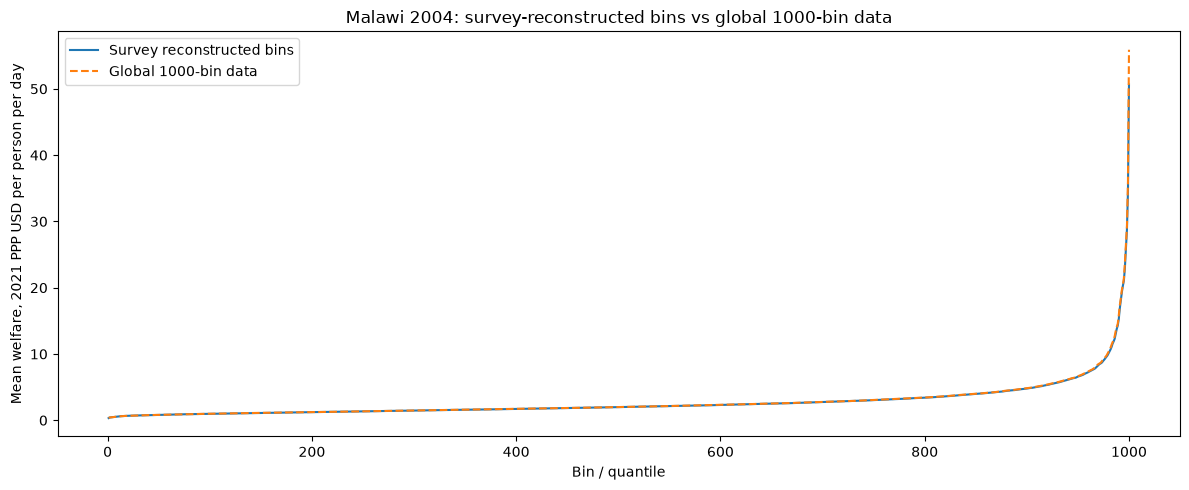

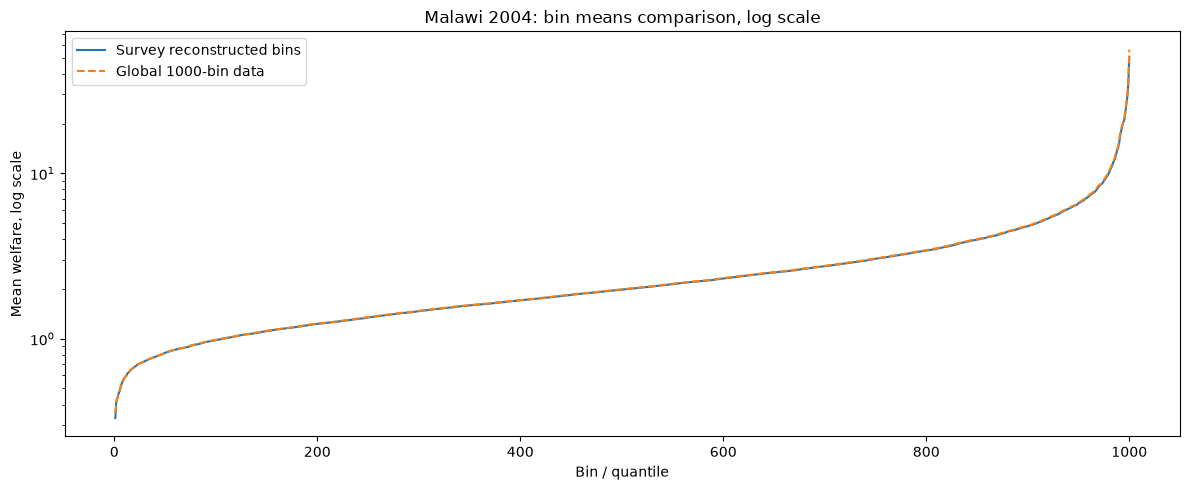

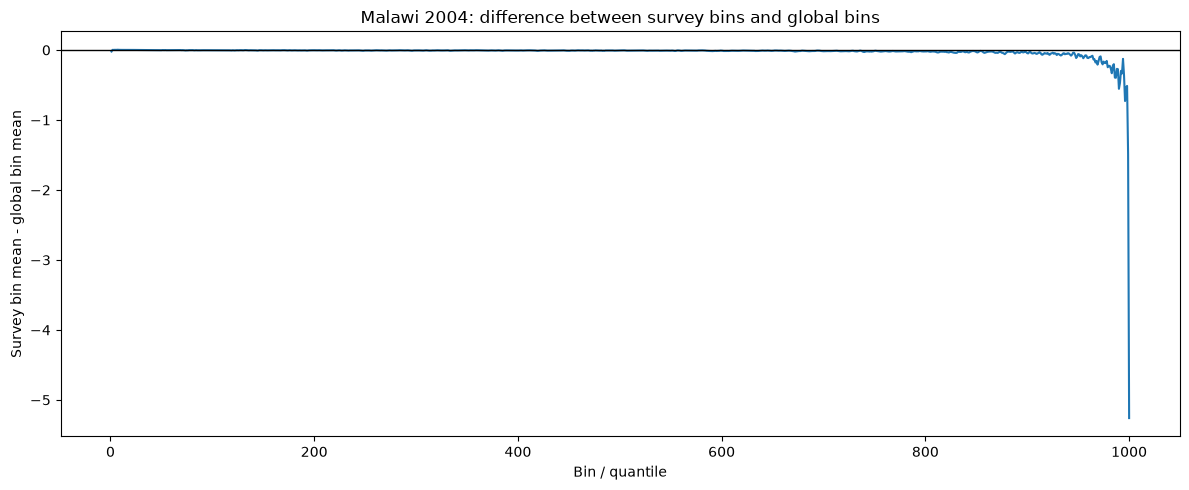

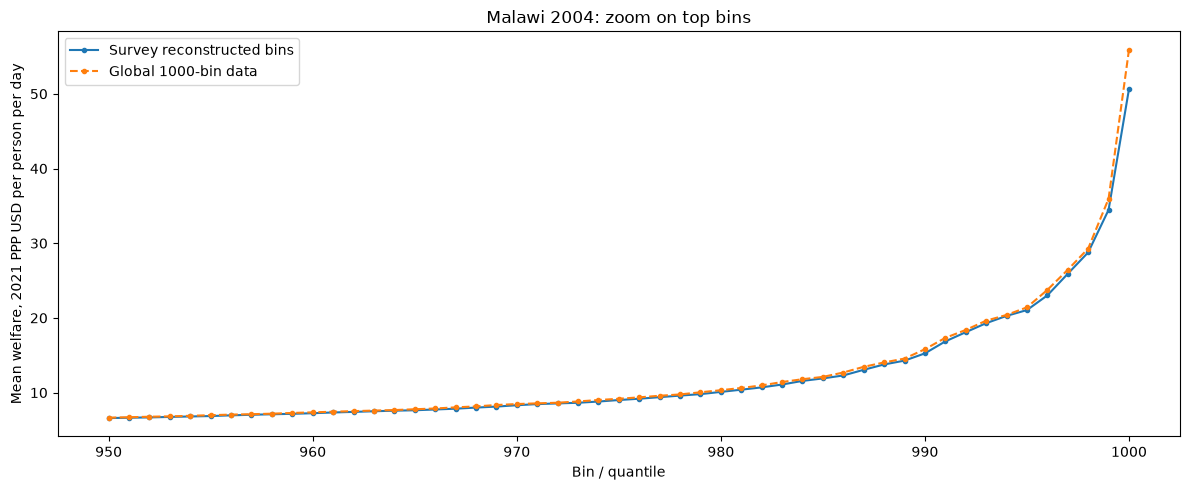

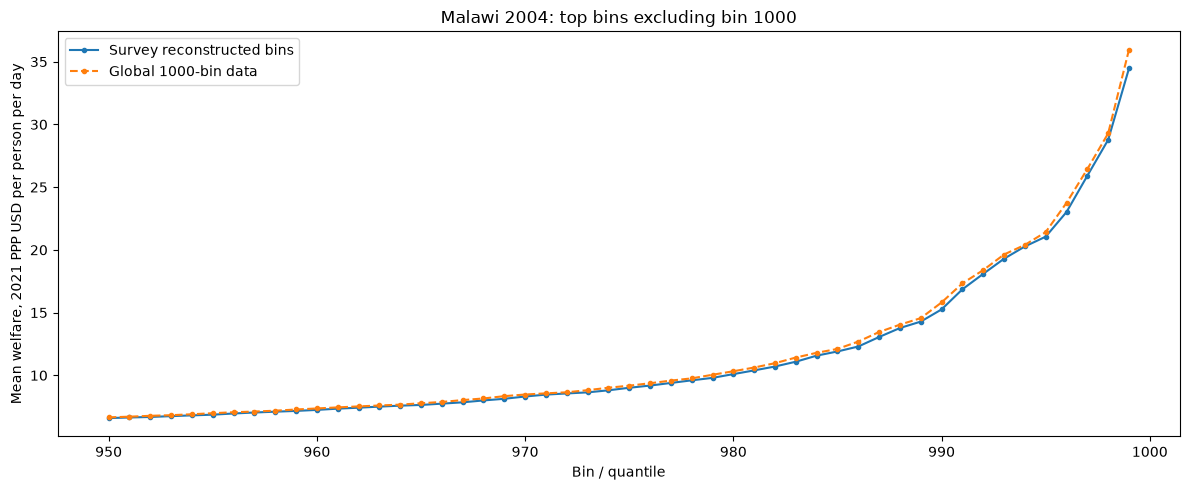

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mwi_bin_comparison["quantile"], mwi_bin_comparison["survey_bin_welf"], label="Survey reconstructed bins", linewidth=1.5)
ax.plot(mwi_bin_comparison["quantile"], mwi_bin_comparison["global_bin_welf"], label="Global 1000-bin data", linewidth=1.5, linestyle="--")
ax.set_title("Malawi 2004: survey-reconstructed bins vs global 1000-bin data")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mwi_bin_comparison["quantile"], mwi_bin_comparison["survey_bin_welf"], label="Survey reconstructed bins", linewidth=1.5)
ax.plot(mwi_bin_comparison["quantile"], mwi_bin_comparison["global_bin_welf"], label="Global 1000-bin data", linewidth=1.5, linestyle="--")
ax.set_yscale("log")
ax.set_title("Malawi 2004: bin means comparison, log scale")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, log scale")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mwi_bin_comparison["quantile"], mwi_bin_comparison["diff_survey_minus_global"], linewidth=1.5)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Malawi 2004: difference between survey bins and global bins")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Survey bin mean - global bin mean")
plt.tight_layout()
plt.show()

top_zoom = mwi_bin_comparison[mwi_bin_comparison["quantile"] >= 950]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(top_zoom["quantile"], top_zoom["survey_bin_welf"], label="Survey reconstructed bins", marker="o", markersize=3, linewidth=1.5)
ax.plot(top_zoom["quantile"], top_zoom["global_bin_welf"], label="Global 1000-bin data", marker="o", markersize=3, linewidth=1.5, linestyle="--")
ax.set_title("Malawi 2004: zoom on top bins")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()
plt.tight_layout()
plt.show()

top_zoom_no_1000 = mwi_bin_comparison[(mwi_bin_comparison["quantile"] >= 950) & (mwi_bin_comparison["quantile"] < 1000)]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(top_zoom_no_1000["quantile"], top_zoom_no_1000["survey_bin_welf"], label="Survey reconstructed bins", marker="o", markersize=3, linewidth=1.5)
ax.plot(top_zoom_no_1000["quantile"], top_zoom_no_1000["global_bin_welf"], label="Global 1000-bin data", marker="o", markersize=3, linewidth=1.5, linestyle="--")
ax.set_title("Malawi 2004: top bins excluding bin 1000")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

If most bins align but the last bin diverges strongly, then the gap between PIP mean and global 1000-bin mean is likely concentrated in the treatment of the top bin.

In [16]:
# Calculate mean directly from reconstructed bins to verify
survey_mean_from_bins_2004 = (mwi_survey_bins["survey_bin_welf"] * mwi_survey_bins["survey_bin_weight"]).sum() / mwi_survey_bins["survey_bin_weight"].sum()
global_mean_from_bins_2004 = (mwi_bin_comparison["global_bin_welf"] * mwi_survey_bins["survey_bin_weight"]).sum() / mwi_survey_bins["survey_bin_weight"].sum()

# Compare all sources
detailed_means_2004 = pd.DataFrame({
    "source": [
        "Survey microdata 2004 (direct)",
        "Survey reconstructed bins 2004 (from bins)",
        "PIP mean 2004 (official)",
        "Global 1000-bin mean 2004 (from global bins)"
    ],
    "mean_welfare": [
        survey_mean_2004,
        survey_mean_from_bins_2004,
        mwi_pip_2004["mean"],
        global_mean_from_bins_2004
    ]
})

print("2004 DETAILED MEANS COMPARISON:")
print(detailed_means_2004)
print("\nDifferences (Survey reconstructed - Global bins):")
print(f"  {survey_mean_from_bins_2004:.4f} - {global_mean_from_bins_2004:.4f} = {survey_mean_from_bins_2004 - global_mean_from_bins_2004:.4f}")
print(f"  Survey bins are {('LOWER' if survey_mean_from_bins_2004 < global_mean_from_bins_2004 else 'HIGHER')} by {abs(survey_mean_from_bins_2004 - global_mean_from_bins_2004):.4f}")

2004 DETAILED MEANS COMPARISON:
                                         source  mean_welfare
0                Survey microdata 2004 (direct)        2.7407
1    Survey reconstructed bins 2004 (from bins)        2.7407
2                      PIP mean 2004 (official)        2.8443
3  Global 1000-bin mean 2004 (from global bins)        2.7706

Differences (Survey reconstructed - Global bins):
  2.7407 - 2.7706 = -0.0299
  Survey bins are LOWER by 0.0299


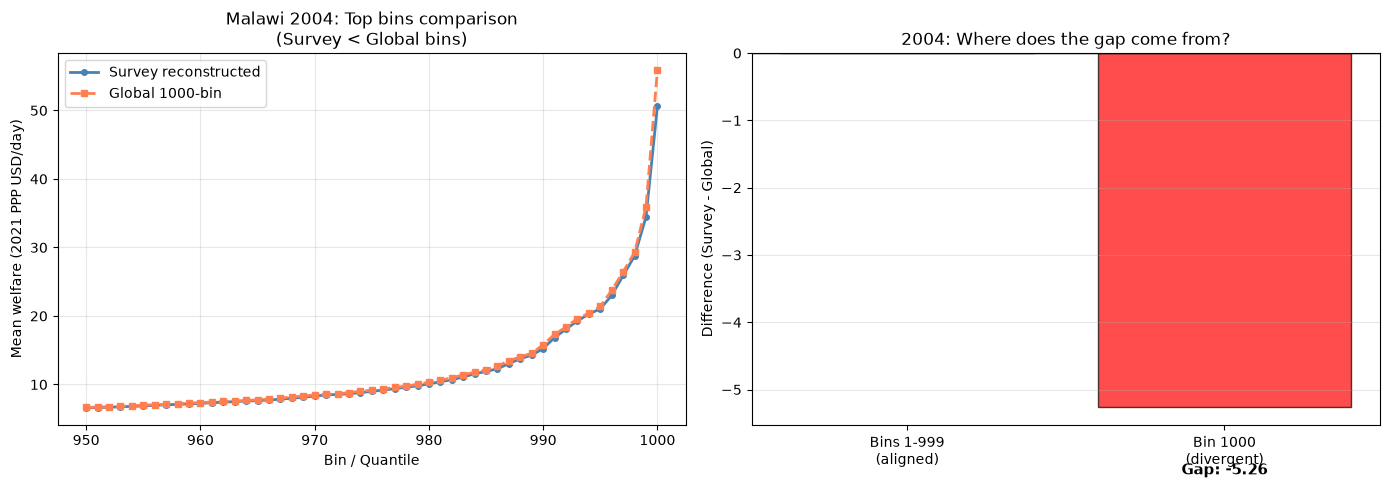


KEY INSIGHT FOR 2004:
  Bin 1000 difference (survey - global): -5.2599
  Ratio (survey / global): 0.9059
  → Survey has LOWER top bin values than global in 2004


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1997: Zoom on top bins (from previous notebook or reconstruct)
# We'll show 2004 detail since we have it, and explain 1997 pattern

# 2004 Zoom - all bins from 950 to 1000
top_zoom_2004 = mwi_bin_comparison[mwi_bin_comparison["quantile"] >= 950]

axes[0].plot(
    top_zoom_2004["quantile"],
    top_zoom_2004["survey_bin_welf"],
    marker="o",
    markersize=4,
    linewidth=2,
    label="Survey reconstructed",
    color="steelblue"
)
axes[0].plot(
    top_zoom_2004["quantile"],
    top_zoom_2004["global_bin_welf"],
    marker="s",
    markersize=4,
    linewidth=2,
    label="Global 1000-bin",
    color="coral",
    linestyle="--"
)
axes[0].set_xlabel("Bin / Quantile")
axes[0].set_ylabel("Mean welfare (2021 PPP USD/day)")
axes[0].set_title("Malawi 2004: Top bins comparison\n(Survey < Global bins)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show the divergence magnitude
divergence = mwi_bin_comparison[mwi_bin_comparison["quantile"] == 1000.0].iloc[0]
axes[1].bar(
    ["Bins 1-999\n(aligned)", "Bin 1000\n(divergent)"],
    [
        0,  # Bins 1-999 are aligned
        divergence["diff_survey_minus_global"]
    ],
    color=["green", "red"],
    alpha=0.7,
    edgecolor="black"
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Difference (Survey - Global)")
axes[1].set_title("2004: Where does the gap come from?")
axes[1].grid(True, alpha=0.3, axis="y")

# Add annotation
axes[1].text(
    1, divergence["diff_survey_minus_global"] - 1,
    f"Gap: {divergence['diff_survey_minus_global']:.2f}",
    ha="center",
    fontsize=11,
    weight="bold"
)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT FOR 2004:")
print(f"  Bin 1000 difference (survey - global): {divergence['diff_survey_minus_global']:.4f}")
print(f"  Ratio (survey / global): {divergence['ratio_survey_global']:.4f}")
print("  → Survey has LOWER top bin values than global in 2004")

In [24]:
# Construir bins propios y bins listos para Malawi 1997 (para comparar metodo a metodo)
cpi2021_1997 = mwi_1997["cpi2021"].dropna().iloc[0]
icp2021_1997 = mwi_1997["icp2021"].dropna().iloc[0]

mwi_1997_processed = mwi_1997[["welfare", "weight"]].dropna().copy()
mwi_1997_processed = mwi_1997_processed[mwi_1997_processed["weight"] > 0].copy()
mwi_1997_processed["welfare_2021ppp_day"] = (
    mwi_1997_processed["welfare"] / (cpi2021_1997 * icp2021_1997 * 365)
)

mwi_1997_survey_bins = weighted_equal_bins(
    mwi_1997_processed,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

chunks_1997 = []
for chunk in pd.read_stata(
    global_bins_path,
    columns=["code", "year", "quantile", "welf", "pop"],
    chunksize=500_000,
):
    chunk["year"] = chunk["year"].astype(int)
    keep = (chunk["code"] == "MWI") & (chunk["year"] == 1997)
    if keep.any():
        chunks_1997.append(chunk.loc[keep].copy())

mwi_1997_global_bins = pd.concat(chunks_1997, ignore_index=True)

mwi_1997_bin_comparison = mwi_1997_survey_bins.merge(
    mwi_1997_global_bins[["quantile", "welf", "pop"]],
    on="quantile",
    how="left",
).rename(columns={"welf": "global_bin_welf", "pop": "global_bin_pop"})

mwi_1997_bin_comparison["diff_survey_minus_global"] = (
    mwi_1997_bin_comparison["survey_bin_welf"] - mwi_1997_bin_comparison["global_bin_welf"]
)
mwi_1997_bin_comparison["ratio_survey_global"] = (
    mwi_1997_bin_comparison["survey_bin_welf"] / mwi_1997_bin_comparison["global_bin_welf"]
)

mwi_1997_bin_comparison.head()

,quantile,survey_bin_welf,survey_bin_weight,global_bin_welf,global_bin_pop,diff_survey_minus_global,ratio_survey_global
0,1.0000,0.3006,"9,666.6481",0.3140,0.0106,-0.0134,0.9573
1,2.0000,0.3551,"9,666.6481",0.3540,0.0106,0.0011,1.0032
2,3.0000,0.3959,"9,666.6481",0.3939,0.0106,0.0020,1.0051
3,4.0000,0.4182,"9,666.6481",0.4164,0.0106,0.0019,1.0045
4,5.0000,0.4380,"9,666.6481",0.4354,0.0106,0.0026,1.0060
